In [ ]:
from google.colab import auth
auth.authenticate_user()
import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from google.colab import drive

drive.mount('/content/gdrive')

df = pd.read_csv('/content/gdrive/My Drive/NCKH/NGHIÊN CỨU KHOA HỌC/Code/P2P_Dataset.csv')
df.head()

Mounted at /content/gdrive


,acc_now_delinq,acc_open_past_24mths,annual_inc,badloan,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earnings,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,0,2,49800.0,0,0,0,0,0,25.120001,995.80,...,False,False,False,False,False,False,False,False,False,False
1,0,3,34000.0,0,0,0,0,0,9.220000,995.80,...,False,False,False,False,False,False,False,False,False,False
2,0,0,34000.0,0,0,0,0,0,25.590000,995.80,...,False,False,False,False,False,False,False,False,False,False
3,0,2,50000.0,1,0,0,0,0,9.310000,750.89,...,False,False,True,False,False,False,False,False,False,False
4,0,2,29000.0,1,0,0,0,0,8.150000,1356.23,...,False,False,False,False,False,False,False,False,False,False


# Định dạng biến

In [ ]:
boolean_cols = df.select_dtypes(include=['bool']).columns
df[boolean_cols] = df[boolean_cols].astype(int)

In [ ]:
df.dtypes

,0
acc_now_delinq,int64
acc_open_past_24mths,int64
annual_inc,float64
badloan,int64
chargeoff_within_12_mths,int64
collections_12_mths_ex_med,int64
delinq_2yrs,int64
delinq_amnt,int64
dti,float64
earnings,float64


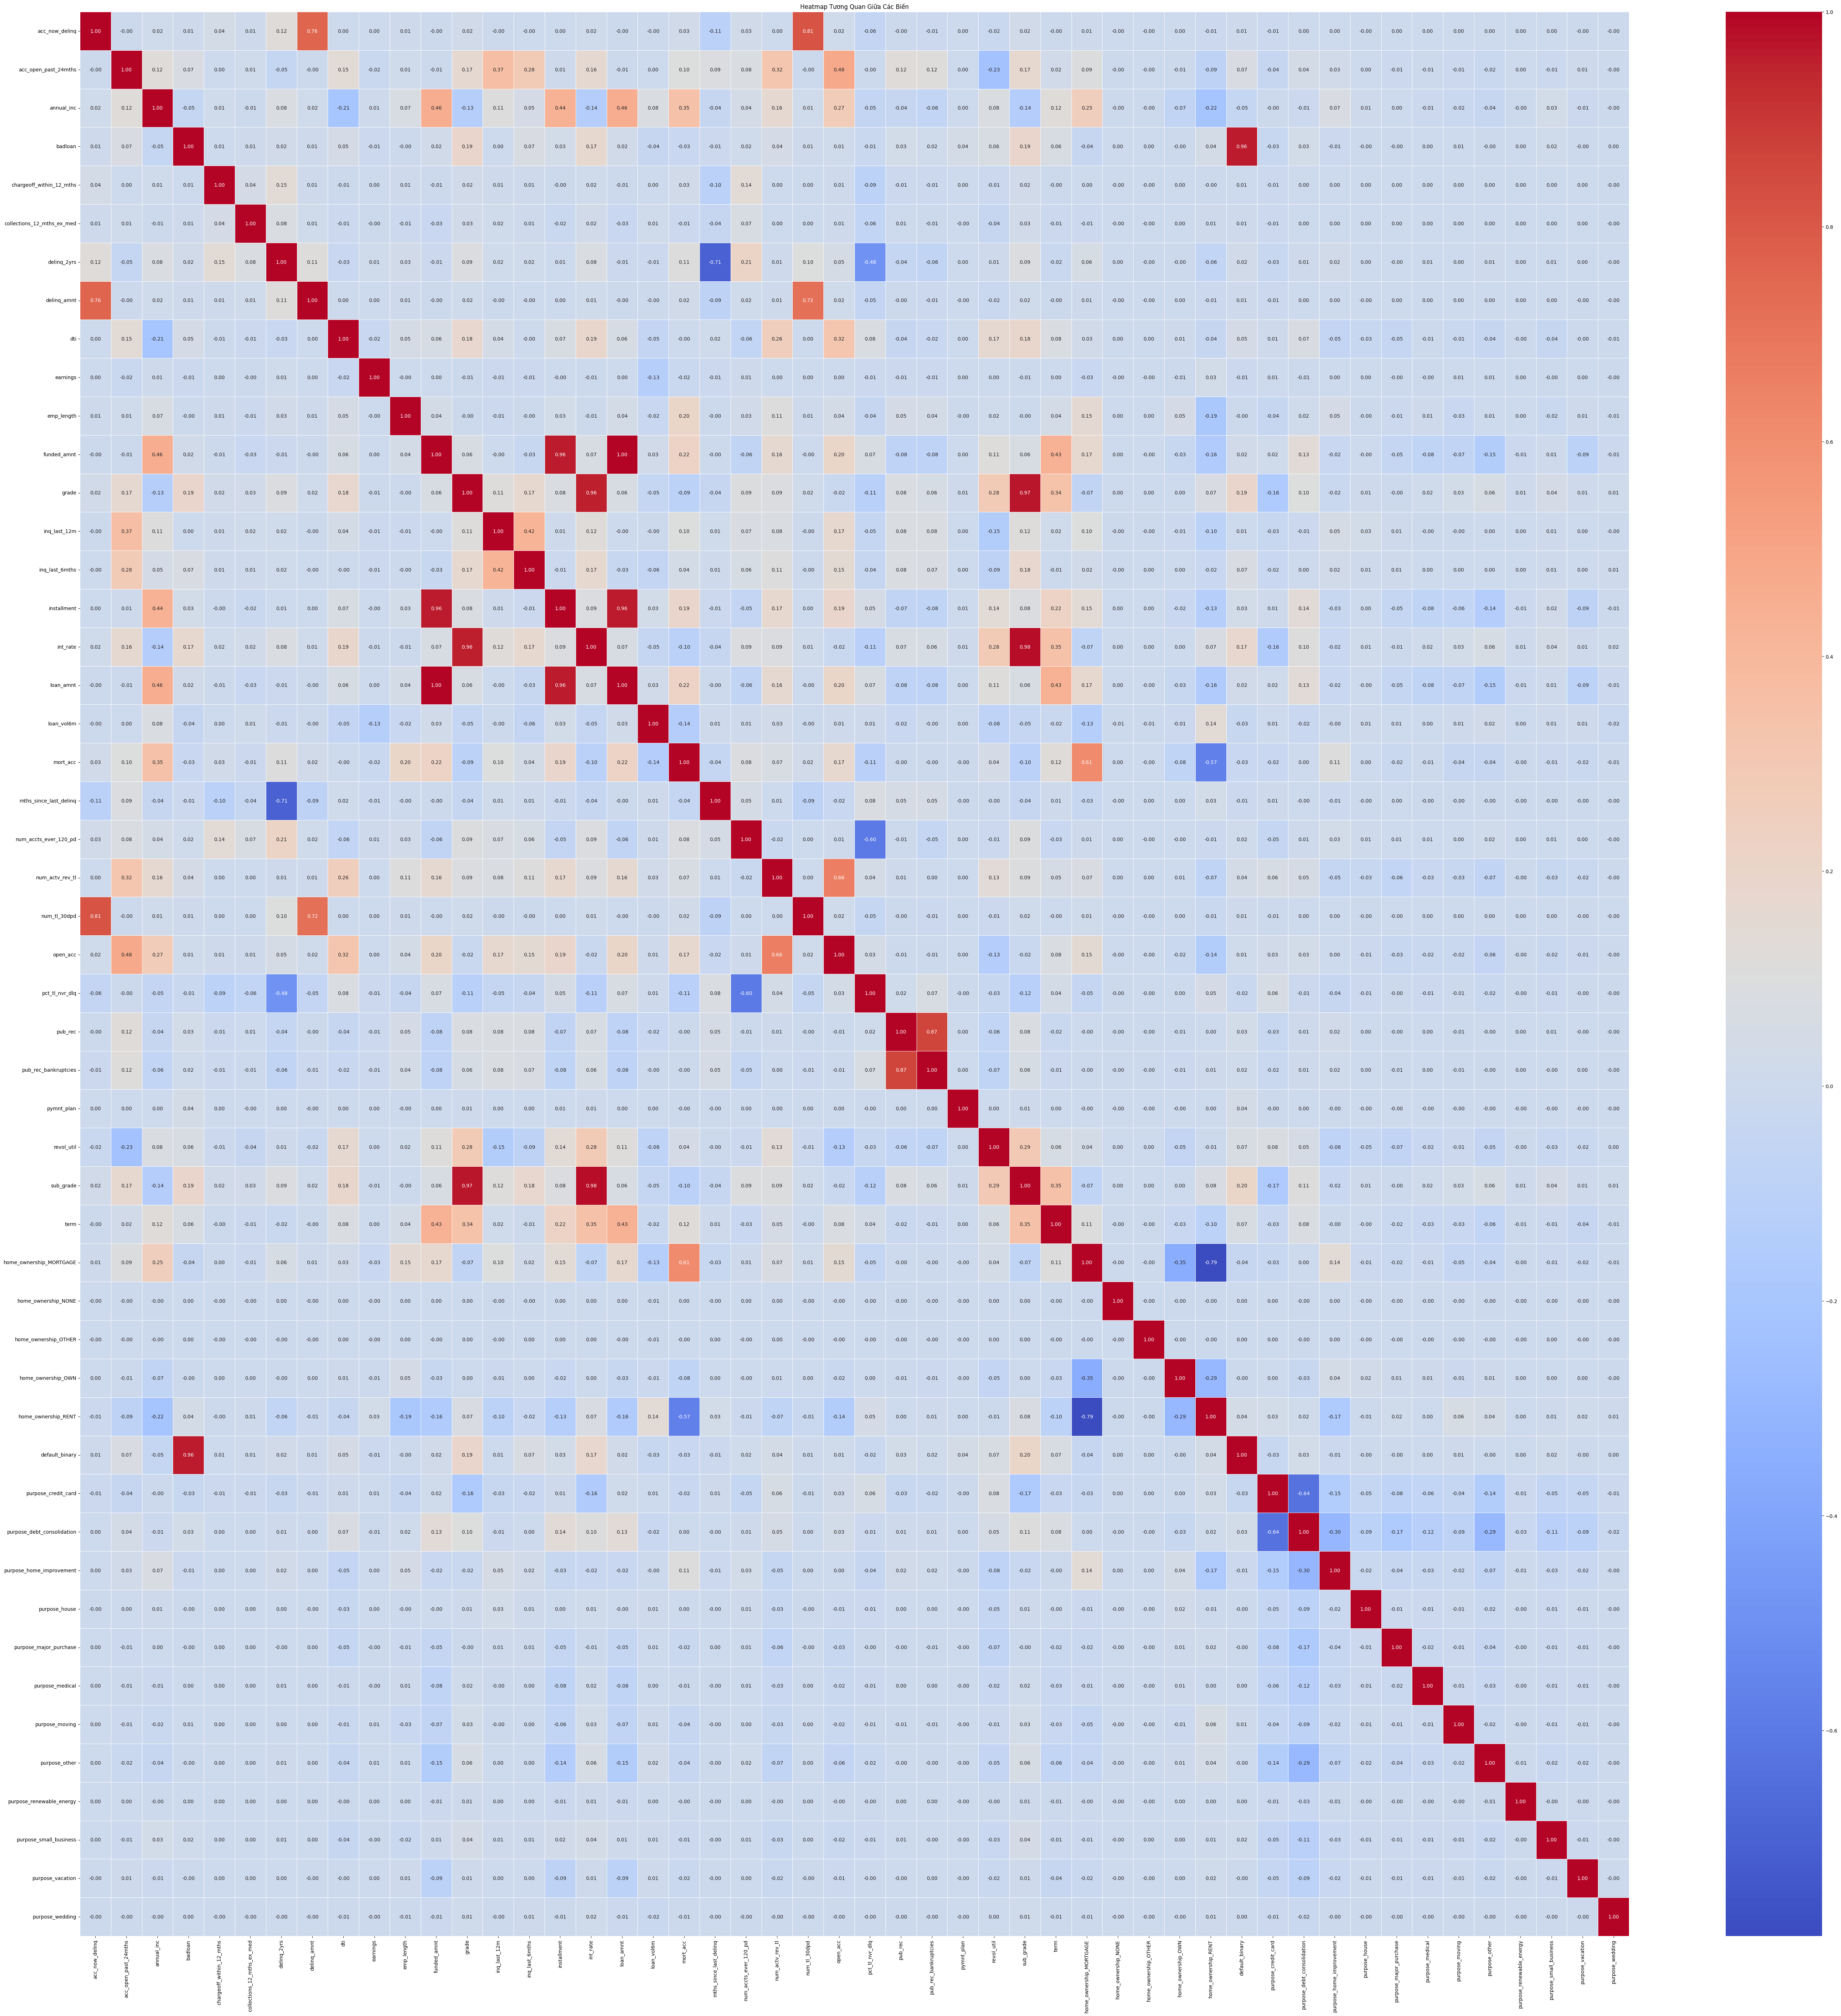

In [ ]:
corr_matrix = df.corr(method='spearman')

# Vẽ heatmap
plt.figure(figsize=(70,70))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Tương Quan Giữa Các Biến")
plt.show()

In [ ]:
# Sắp xếp theo mức độ tương quan
corr_target = corr_matrix["default_binary"].sort_values(ascending=False)
print(corr_target)

default_binary                1.000000
badloan                       0.960499
sub_grade                     0.195720
grade                         0.193027
int_rate                      0.174670
acc_open_past_24mths          0.073960
inq_last_6mths                0.072828
revol_util                    0.066184
term                          0.065637
dti                           0.047762
num_actv_rev_tl               0.040679
home_ownership_RENT           0.038590
pymnt_plan                    0.035204
purpose_debt_consolidation    0.031897
installment                   0.031253
pub_rec                       0.028889
funded_amnt                   0.024566
loan_amnt                     0.024566
delinq_2yrs                   0.023380
num_accts_ever_120_pd         0.019363
pub_rec_bankruptcies          0.017235
purpose_small_business        0.016010
open_acc                      0.013908
acc_now_delinq                0.009450
delinq_amnt                   0.008398
num_tl_30dpd             

In [ ]:
df = df.drop(columns=["badloan", "funded_amnt", "sub_grade", "pub_rec", "num_tl_30dpd"])

#Logistic Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
X = df.drop(columns=["default_binary"])
y = df["default_binary"]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Chuẩn hóa các biến độc lập

# Huấn luyện lại mô hình
model = LogisticRegression()
model.fit(X_scaled, y)

# Kiểm tra lại hệ số hồi quy
importance = model.coef_[0]
print(importance)

[ 9.45681526e-03  2.18949405e-01 -2.80592896e-01  3.61522279e-03
  1.20974587e-02  5.54560411e-02  3.67044826e-03 -1.68654342e-02
 -5.35073450e-02 -1.48167328e-03  1.03542875e+00 -1.53315651e-01
  1.39078899e-01  3.03592297e-01 -5.75660264e-01 -2.50275995e-01
 -7.70718709e-02 -5.43204043e-03 -2.77132800e-02 -5.79848167e-04
  4.93934730e-02 -7.66696255e-02  1.90510516e-02  1.91607353e-02
  7.98032056e-02  1.40122298e-01  1.10078658e-01 -5.63459077e-02
  1.31562174e-03  2.54655275e-03  4.89058245e-03  8.51852227e-02
  4.21577266e-02  9.74147583e-02  5.78347703e-02  2.57439953e-03
  2.93130627e-02  2.59619892e-02  2.10437379e-02  2.58208274e-02
  6.45199484e-03  4.08245033e-02  8.76993429e-03  1.65278719e-03]


In [ ]:
for i, v in enumerate(importance):
    print(f'Biến: {X.columns[i]}, Tầm quan trọng: {v:.5f}')

Biến: acc_now_delinq, Tầm quan trọng: 0.00946
Biến: acc_open_past_24mths, Tầm quan trọng: 0.21895
Biến: annual_inc, Tầm quan trọng: -0.28059
Biến: chargeoff_within_12_mths, Tầm quan trọng: 0.00362
Biến: collections_12_mths_ex_med, Tầm quan trọng: 0.01210
Biến: delinq_2yrs, Tầm quan trọng: 0.05546
Biến: delinq_amnt, Tầm quan trọng: 0.00367
Biến: dti, Tầm quan trọng: -0.01687
Biến: earnings, Tầm quan trọng: -0.05351
Biến: emp_length, Tầm quan trọng: -0.00148
Biến: grade, Tầm quan trọng: 1.03543
Biến: inq_last_12m, Tầm quan trọng: -0.15332
Biến: inq_last_6mths, Tầm quan trọng: 0.13908
Biến: installment, Tầm quan trọng: 0.30359
Biến: int_rate, Tầm quan trọng: -0.57566
Biến: loan_amnt, Tầm quan trọng: -0.25028
Biến: loan_vol6m, Tầm quan trọng: -0.07707
Biến: mort_acc, Tầm quan trọng: -0.00543
Biến: mths_since_last_delinq, Tầm quan trọng: -0.02771
Biến: num_accts_ever_120_pd, Tầm quan trọng: -0.00058
Biến: num_actv_rev_tl, Tầm quan trọng: 0.04939
Biến: open_acc, Tầm quan trọng: -0.07667
Biến

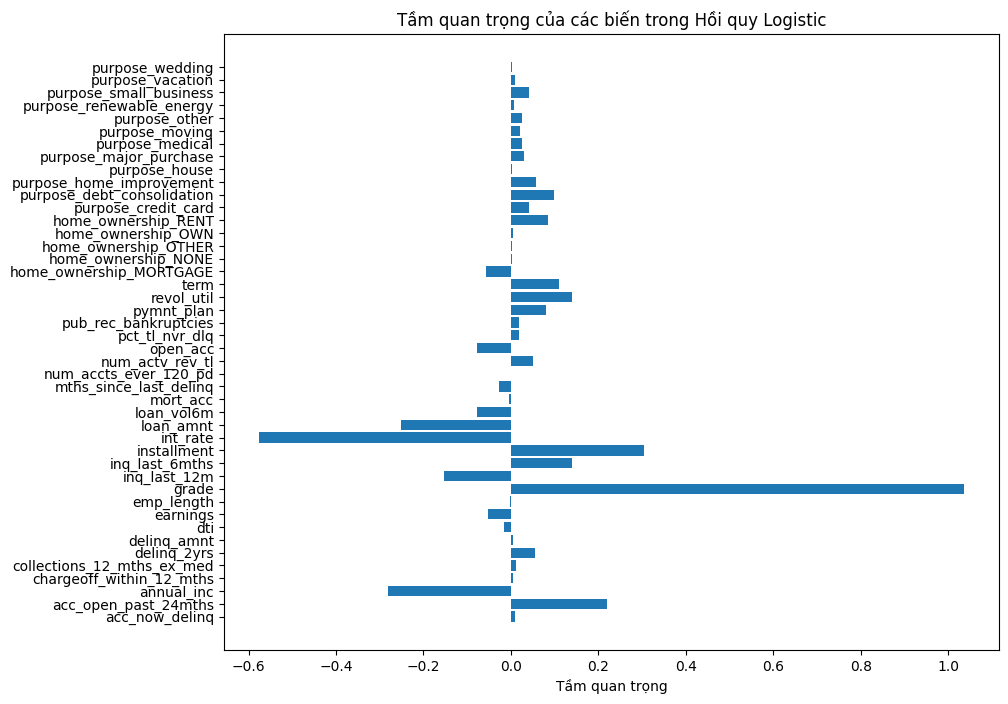

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Tạo biểu đồ cột
plt.figure(figsize=(10, 8))
plt.barh(np.arange(len(importance)), importance, align='center')
plt.yticks(np.arange(len(importance)), X.columns)
plt.xlabel('Tầm quan trọng')
plt.title('Tầm quan trọng của các biến trong Hồi quy Logistic')
plt.show()

Loại bỏ các biến có mức ảnh hưởng dưới 0.01
Giữ lại các biến có mức ảnh hưởng trên 0.01

**Đưa vào tệp dữ liệu riêng dành cho mô hình Logistic**

In [ ]:
df1 = df.drop(columns=["acc_now_delinq", "chargeoff_within_12_mths", "delinq_amnt", "emp_length", "mort_acc", "num_accts_ever_120_pd",
              "home_ownership_NONE", "home_ownership_OTHER", "purpose_house", "purpose_renewable_energy", "purpose_vacation", "purpose_wedding"])

## Mô hình huấn luyện Logistic

In [ ]:
import optuna
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# Bước 2: Tạo X, y
X = df1.drop(columns=["default_binary"], errors="ignore")
y = df1["default_binary"]

# Bước 3: Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

# 🌟 Áp dụng SMOTE để cân bằng dữ liệu
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Bước 4: Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Bước 5: Hàm tối ưu siêu tham số bằng Optuna
def objective(trial):
    C = trial.suggest_loguniform('C', 1e-5, 100)
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga'])

    model = LogisticRegression(C=C, solver=solver, max_iter=1000)
    model.fit(X_train_scaled, y_train_resampled)

    y_pred = model.predict(X_test_scaled)
    return roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

# Bước 6: Chạy Optuna để tìm siêu tham số tối ưu
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Bước 7: Huấn luyện mô hình với siêu tham số tốt nhất
best_params = study.best_params
best_model = LogisticRegression(**best_params, max_iter=1000)
best_model.fit(X_train_scaled, y_train_resampled)

# Bước 8: Dự đoán
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]  # Xác suất dự đoán cho lớp 1

# Bước 9: Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
report = classification_report(y_test, y_pred)

# Bước 10: In kết quả
print("\n📊 Logistic Regression Model with SMOTE Evaluation")
print(f"🎯 Best Hyperparameters: {best_params}")
print(f"🎯 Accuracy: {accuracy:.4f}")
print(f"🚀 AUC-ROC: {roc_auc:.4f}")
print(f"📑 Classification Report:\n{report}")
print(f"📊 Confusion Matrix:\n{conf_matrix}")

[I 2025-03-17 17:44:27,568] A new study created in memory with name: no-name-c4d22c75-cb85-42e8-8b0f-241cd53afcdc
<ipython-input-11-5fff7f9f8e3c>:27: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1e-5, 100)
[I 2025-03-17 18:01:10,362] Trial 0 finished with value: 0.6269368967888829 and parameters: {'C': 0.00045646701130468804, 'solver': 'saga'}. Best is trial 0 with value: 0.6269368967888829.
<ipython-input-11-5fff7f9f8e3c>:27: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1e-5, 100)
[I 2025-03-17 18:17:42,042] Trial 1 finished with value: 0.6270723881214374 and parameters: {'C': 0.0003597188657319985, 